In [124]:
"""
Shark Attack Severity Predictor — Random Forest Model
Dataset: California Shark Incidents 1950–2022
Target: Predict injury severity (Minor / Major / Fatal)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

In [125]:
PALETTE = {"Fatal": "#c0392b", "Major": "#e67e22", "Minor": "#27ae60"}
COLORS  = ["#2c3e50", "#2980b9", "#27ae60", "#e67e22", "#c0392b", "#8e44ad"]
plt.rcParams.update({
    "figure.facecolor": "#f9f9f9",
    "axes.facecolor":   "#ffffff",
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


In [126]:
df = pd.read_csv("SharkIncidents_1950_2022.csv")

In [127]:
df.head(2)

,IncidentNum,Date,Time,County,Location,Mode,Injury,Depth,Species,Comment,Longitude,Latitude,Confirmed Source,WFL Case #
0,1,10/8/50,12:00,San Diego,Imperial Beach,Swimming,Major,surface,Great White,"Body Surfing, bit multiple times on leg, thigh...",-117.146667,32.588333,"Miller/Collier, Coronado Paper, Oceanside Paper",NaN
1,2,5/27/52,14:00,San Diego,Imperial Beach,Swimming,Minor,surface,Great White,Foot & swim fin bitten,-117.246667,32.588333,GSAF - with photos,NaN


In [128]:
# ── Date features ─────────────────────────────────────────────────────────────
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%y", errors="coerce")
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Season"] = df["Month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring",  4: "Spring", 5: "Spring",
    6: "Summer",  7: "Summer", 8: "Summer",
    9: "Fall",   10: "Fall",  11: "Fall",
})

# ── Time of day ───────────────────────────────────────────────────────────────
def parse_hour(t):
    try:
        return int(str(t).split(":")[0])
    except Exception:
        return np.nan

df["Hour"] = df["Time"].apply(parse_hour)
df["TimeOfDay"] = pd.cut(
    df["Hour"],
    bins=[-1, 6, 12, 17, 20, 24],
    labels=["Night", "Morning", "Afternoon", "Evening", "Night2"],
)
df["TimeOfDay"] = df["TimeOfDay"].astype(str).replace("Night2", "Night")

# ── Depth ─────────────────────────────────────────────────────────────────────
def parse_depth(d):
    try:
        return float(d)
    except Exception:
        return 0.0   # 'surface' or 'Unknown' → 0

df["DepthNum"] = df["Depth"].apply(parse_depth)
df["IsSubmerged"] = (df["DepthNum"] > 0).astype(int)

# ── Drop rows where target is missing ─────────────────────────────────────────
df = df.dropna(subset=["Injury"])
print(f"Working dataset: {len(df)} incidents\n")


Working dataset: 123 incidents



In [129]:
FEATURES = ["Mode", "Species", "County", "Season", "TimeOfDay",
            "IsSubmerged", "DepthNum", "Month", "Year"]
TARGET   = "Injury"

# Fill remaining NAs with 'Unknown'
for col in ["Mode", "Species", "County", "Season", "TimeOfDay"]:
    df[col] = df[col].fillna("Unknown").astype(str)

# Label-encode categorical features
le_dict = {}
X = df[FEATURES].copy()
for col in ["Mode", "Species", "County", "Season", "TimeOfDay"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

y_le = LabelEncoder()
y = y_le.fit_transform(df[TARGET])
class_names = y_le.classes_          # ['Fatal', 'Major', 'Minor']

print("Class distribution:")
for cls, cnt in zip(class_names, np.bincount(y)):
    print(f"  {cls:8s}: {cnt}")
print()

Class distribution:
  Fatal   : 15
  Major   : 59
  Minor   : 49



In [130]:
#Random Forest Model
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
rf = RandomForestClassifier(
n_estimators=200,
max_depth=None,
min_samples_split=2,
class_weight="balanced",
random_state=42,
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
#Cross-validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")
print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"Test accuracy : {(y_pred == y_test).mean():.3f}")
print(f"CV accuracy (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

print()
print(classification_report(y_test, y_pred, target_names=class_names))

MODEL PERFORMANCE
Test accuracy : 0.640
CV accuracy (5-fold): 0.577 ± 0.069

              precision    recall  f1-score   support

       Fatal       0.33      0.33      0.33         3
       Major       0.69      0.75      0.72        12
       Minor       0.67      0.60      0.63        10

    accuracy                           0.64        25
   macro avg       0.56      0.56      0.56        25
weighted avg       0.64      0.64      0.64        25



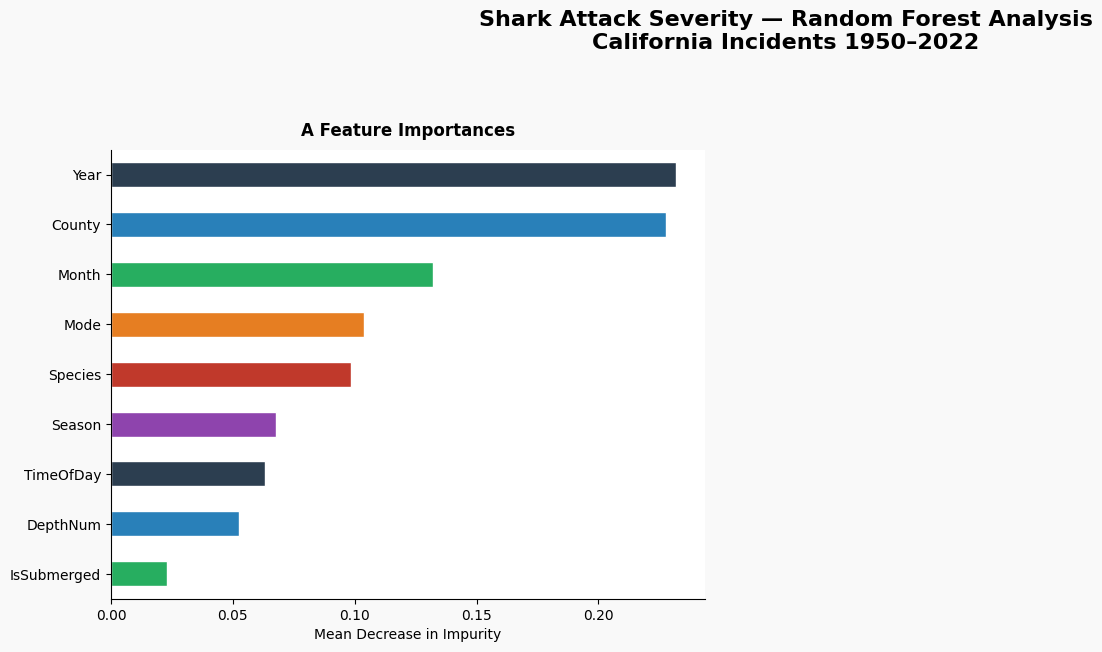

In [131]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Shark Attack Severity — Random Forest Analysis\nCalifornia Incidents 1950–2022",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Panel A: Feature Importance
ax1 = fig.add_subplot(gs[0, 0])
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
colors_bar = [COLORS[i % len(COLORS)] for i in range(len(feat_imp))]
feat_imp.plot(kind="barh", ax=ax1, color=colors_bar[::-1], edgecolor="white")

ax1.set_title("A Feature Importances", fontweight="bold", pad=10)
ax1.set_xlabel("Mean Decrease in Impurity")

for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

In [132]:
# 1. Clean Categorical Features using Pandas 'category' dtype
categorical_cols = ["Mode", "Species", "County", "Season", "TimeOfDay"]
numeric_cols = ["IsSubmerged", "DepthNum", "Month", "Year"]

X = df[categorical_cols + numeric_cols].copy()

for col in categorical_cols:
    X[col] = X[col].fillna("Unknown").astype("category")

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Encode Target
y_le = LabelEncoder()
y = y_le.fit_transform(df[TARGET])
class_names = y_le.classes_

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Native XGBoost (enable_categorical=True, no aggressive sample weights)
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,              # Standard default depth
    learning_rate=0.1,
    enable_categorical=True,  # Handles categories without LabelEncoder bias
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

# ── Cross-Validation ──────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in cv.split(X, y):
    X_cv_train, X_cv_val = X.iloc[train_idx], X.iloc[val_idx]
    y_cv_train, y_cv_val = y[train_idx], y[val_idx]
    
    cv_xgb = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        enable_categorical=True, random_state=42, eval_metric='mlogloss'
    )
    cv_xgb.fit(X_cv_train, y_cv_train)
    cv_scores.append(cv_xgb.score(X_cv_val, y_cv_val))

cv_scores = np.array(cv_scores)

print("=" * 50)
print("NATIVE CATEGORICAL XGBOOST PERFORMANCE")
print("=" * 50)
print(f"Test accuracy       : {(y_pred == y_test).mean():.3f}")
print(f"CV accuracy (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names))

NATIVE CATEGORICAL XGBOOST PERFORMANCE
Test accuracy       : 0.680
CV accuracy (5-fold): 0.570 ± 0.088

              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00         3
       Major       0.71      0.83      0.77        12
       Minor       0.70      0.70      0.70        10

    accuracy                           0.68        25
   macro avg       0.47      0.51      0.49        25
weighted avg       0.62      0.68      0.65        25



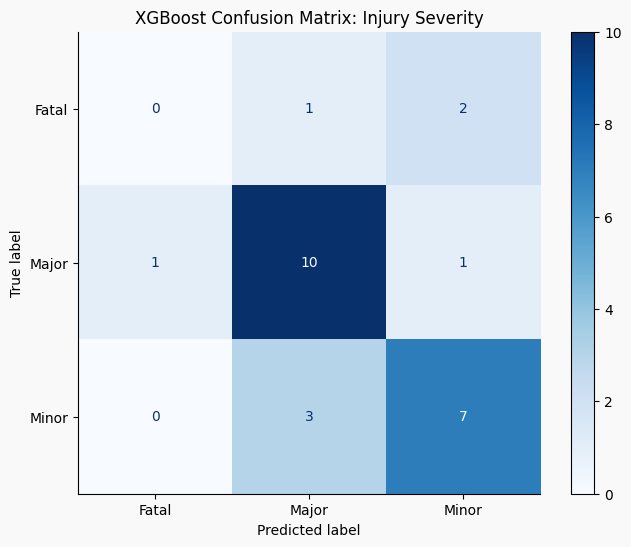

In [133]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it with a nice color map
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("XGBoost Confusion Matrix: Injury Severity")
plt.grid(False) # Hides grid lines for cleaner look
plt.show()

XGBOOST PERFORMANCE (WITH FEATURE ENGINEERING)
Test accuracy: 0.680

              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00         3
       Major       0.77      0.83      0.80        12
       Minor       0.58      0.70      0.64        10

    accuracy                           0.68        25
   macro avg       0.45      0.51      0.48        25
weighted avg       0.60      0.68      0.64        25



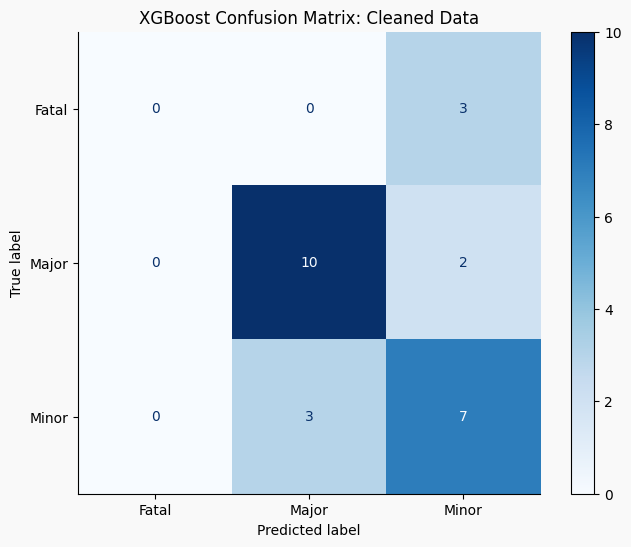

In [134]:
# 2. Feature Engineering: Group Rare Categories
# Group rare Species (appear less than 5 times)
species_counts = df['Species'].value_counts()
valid_species = species_counts[species_counts >= 5].index
df['Species_Clean'] = df['Species'].apply(lambda x: x if x in valid_species else 'Other')

# Group rare Counties (appear less than 5 times)
county_counts = df['County'].value_counts()
valid_counties = county_counts[county_counts >= 5].index
df['County_Clean'] = df['County'].apply(lambda x: x if x in valid_counties else 'Other')

# 3. Define Features and Target
categorical_cols = ["Mode", "Species_Clean", "County_Clean", "Season", "TimeOfDay"]
numeric_cols = ["IsSubmerged", "DepthNum", "Month", "Year"]
TARGET = "Injury"

# 4. Handle Missing Values & Convert to Native Categories for XGBoost
X = df[categorical_cols + numeric_cols].copy()

for col in categorical_cols:
    X[col] = X[col].fillna("Unknown").astype("category")

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# 5. Encode Target Variable
y_le = LabelEncoder()
y = y_le.fit_transform(df[TARGET])
class_names = y_le.classes_

# 6. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Train Native XGBoost Classifier
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    enable_categorical=True,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

# 8. Predictions and Evaluation
y_pred = xgb.predict(X_test)

print("=" * 50)
print("XGBOOST PERFORMANCE (WITH FEATURE ENGINEERING)")
print("=" * 50)
print(f"Test accuracy: {(y_pred == y_test).mean():.3f}\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# 9. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("XGBoost Confusion Matrix: Cleaned Data")
plt.grid(False)
plt.show()

XGBOOST PERFORMANCE (TOP 4 FEATURES + OVERSAMPLING)
Test accuracy: 0.560

              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00         3
       Major       0.64      0.58      0.61        12
       Minor       0.54      0.70      0.61        10

    accuracy                           0.56        25
   macro avg       0.39      0.43      0.41        25
weighted avg       0.52      0.56      0.54        25



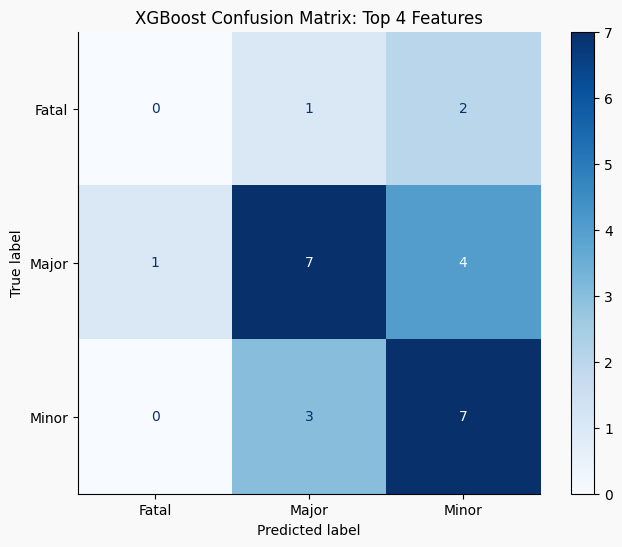

In [135]:
# 2. Extract Top 4 Features Based on Importance Chart
top_categorical = ["County", "Mode"]
top_numeric = ["Year", "Month"]
TARGET = "Injury"

# 3. Clean 'County' (Keep categories with >= 5 occurrences, else 'Other')
county_counts = df['County'].value_counts()
valid_counties = county_counts[county_counts >= 5].index
df['County_Clean'] = df['County'].apply(lambda x: x if x in valid_counties else 'Other')

# Update our categorical list to use the cleaned county column
final_categorical = ["County_Clean", "Mode"]

# 4. Filter Dataset to Top Features & Handle Missing Values
X = df[final_categorical + top_numeric].copy()

# Set up Native XGBoost Categories
for col in final_categorical:
    X[col] = X[col].fillna("Unknown").astype("category")

for col in top_numeric:
    X[col] = X[col].fillna(X[col].median())

# 5. Encode Target Variable
y_le = LabelEncoder()
y = y_le.fit_transform(df[TARGET])
class_names = y_le.classes_

# 6. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Apply Random Oversampling to Fix Imbalance
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# 8. Train Streamlined Native XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    enable_categorical=True,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train_resampled, y_train_resampled)

# 9. Evaluate Predictions
y_pred = xgb.predict(X_test)

print("=" * 50)
print("XGBOOST PERFORMANCE (TOP 4 FEATURES + OVERSAMPLING)")
print("=" * 50)
print(f"Test accuracy: {(y_pred == y_test).mean():.3f}\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# 10. Plot Final Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("XGBoost Confusion Matrix: Top 4 Features")
plt.grid(False)
plt.show()

In [136]:
# 1. Define feature types
categorical_cols = ["Mode", "Species", "County", "Season", "TimeOfDay"]
numeric_cols = ["IsSubmerged", "DepthNum", "Month", "Year"]
TARGET = "Injury"

# 2. Fill missing values 
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown").astype(str)

# Ensure numeric columns don't have NAs (using median imputation as a baseline)
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# 3. Target encoding (LabelEncoder is perfect for the target variable 'y')
y_le = LabelEncoder()
y = y_le.fit_transform(df[TARGET])
class_names = y_le.classes_

# Separate features
X = df[categorical_cols + numeric_cols]

# 4. Build the Preprocessor
# This applies StandardScaler to numbers and OneHotEncoder to categories
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# 5. Create the SVM Pipeline
# Note: class_weight='balanced' is crucial because Fatal attacks are usually rare!
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42))
])

# 6. Train/Test Split (Stratify ensures equal class proportions in train and test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Fit and Evaluate
print("Training the SVM model...")
svm_pipeline.fit(X_train, y_train)

y_pred = svm_pipeline.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Training the SVM model...

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.17      0.33      0.22         3
       Major       0.64      0.58      0.61        12
       Minor       0.50      0.40      0.44        10

    accuracy                           0.48        25
   macro avg       0.43      0.44      0.43        25
weighted avg       0.53      0.48      0.50        25



In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
#!pip install xgboost
from xgboost import XGBClassifier

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Compute balanced sample weights for training set
sample_weights_train = compute_sample_weight('balanced', y_train)

# 2. Define XGBoost Classifier with tuned hyperparameters for smaller datasets
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,            # Lower depth (3-5) prevents overfitting on smaller datasets
    learning_rate=0.05,     # Slower learning rate allows finer convergence
    subsample=0.8,          # Uses 80% of data per tree to add randomness
    colsample_bytree=0.8,   # Uses 80% of features per tree
    random_state=42,
    eval_metric='mlogloss'
)

# 3. Fit model using sample weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train)

# Predict on test set
y_pred = xgb_model.predict(X_test)

# ── Cross-validation with Sample Weights ──────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

# Loop through CV folds to calculate sample weights dynamically per fold
for train_idx, val_idx in cv.split(X, y):
    X_cv_train, X_cv_val = X.iloc[train_idx], X.iloc[val_idx]
    y_cv_train, y_cv_val = y[train_idx], y[val_idx]
    
    # Weight only the current fold's training data to avoid data leakage
    sw_cv = compute_sample_weight('balanced', y_cv_train)
    
    cv_xgb = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='mlogloss'
    )
    cv_xgb.fit(X_cv_train, y_cv_train, sample_weight=sw_cv)
    
    cv_scores.append(cv_xgb.score(X_cv_val, y_cv_val))

cv_scores = np.array(cv_scores)

print("=" * 50)
print("WEIGHTED XGBOOST PERFORMANCE")
print("=" * 50)
print(f"Test accuracy       : {(y_pred == y_test).mean():.3f}")
print(f"CV accuracy (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names))

In [140]:
#!pip install catboost
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

categorical_cols = ["Mode", "Species", "County", "Season", "TimeOfDay"]
numeric_cols = ["IsSubmerged", "DepthNum", "Month", "Year"]
FEATURES = categorical_cols + numeric_cols
TARGET = "Injury"

X = df[FEATURES].copy()

# Fill missing values
for col in categorical_cols:
    X[col] = X[col].fillna("Unknown").astype(str)

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

y = df[TARGET]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize CatBoost with categorical features specified
model = CatBoostClassifier(
    cat_features=categorical_cols,
    auto_class_weights='Balanced',  # Automatically compensates for imbalanced Injury classes
    iterations=300,
    depth=5,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("CatBoost Performance:")
print(classification_report(y_test, y_pred))

CatBoost Performance:
              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00         3
       Major       0.52      0.92      0.67        12
       Minor       0.75      0.30      0.43        10

    accuracy                           0.56        25
   macro avg       0.42      0.41      0.37        25
weighted avg       0.55      0.56      0.49        25



Figure saved → shark_rf_breakdowns.png


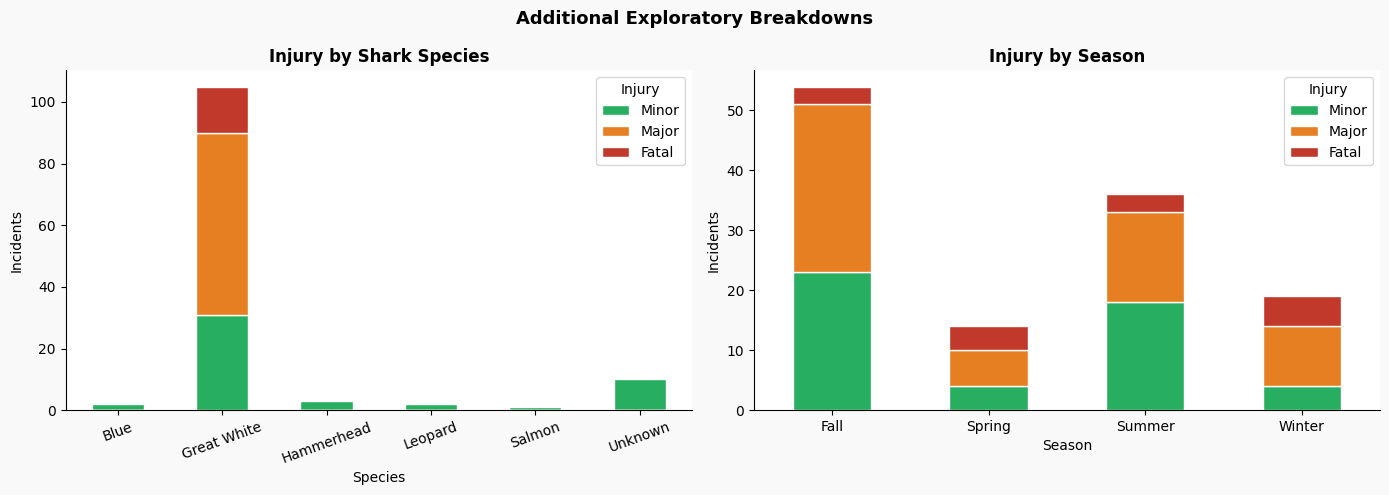

In [139]:
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Additional Exploratory Breakdowns", fontsize=13, fontweight="bold")

# Species
species_injury = (
    df.groupby(["Species", "Injury"])
    .size().unstack(fill_value=0)
    .reindex(columns=["Minor", "Major", "Fatal"])
)
species_injury.plot(
    kind="bar", ax=axes[0], stacked=True,
    color=[PALETTE["Minor"], PALETTE["Major"], PALETTE["Fatal"]],
    edgecolor="white"
)
axes[0].set_title("Injury by Shark Species", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylabel("Incidents")
for sp in ["top", "right"]: axes[0].spines[sp].set_visible(False)

# Season
season_injury = (
    df.groupby(["Season", "Injury"])
    .size().unstack(fill_value=0)
    .reindex(columns=["Minor", "Major", "Fatal"])
)
season_injury.plot(
    kind="bar", ax=axes[1], stacked=True,
    color=[PALETTE["Minor"], PALETTE["Major"], PALETTE["Fatal"]],
    edgecolor="white"
)
axes[1].set_title("Injury by Season", fontweight="bold")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylabel("Incidents")
for sp in ["top", "right"]: axes[1].spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig("shark_rf_breakdowns.png",
            dpi=150, bbox_inches="tight")
print("Figure saved → shark_rf_breakdowns.png")
